```markdown
# Tipos de Variáveis

Em Data Science e Machine Learning, as variáveis representam características ou informações de um conjunto de dados.

Podemos classificá-las em dois grupos principais:

- **Variáveis Numéricas**
- **Variáveis Categóricas**

## 🔢 Variáveis Numéricas

Representam valores quantitativos, ou seja, informações que podem ser medidas ou contadas.

### Contínuas

Podem assumir qualquer valor dentro de um intervalo, incluindo valores decimais.

**Exemplos:**
- Altura: `1.87 m`
- Peso: `82.5 kg`
- Temperatura: `23.7 °C`
- Preço: `R$ 19.99`

### Discretas

Representam valores que podem ser contados e normalmente são números inteiros.

**Exemplos:**
- Número de clientes: `150`
- Quantidade de produtos: `8`
- Número de vendas: `35`
- Número de filhos: `2`

---

## 🏷️ Variáveis Categóricas

Representam grupos ou categorias.

### Nominais

São categorias que **não possuem uma ordem ou hierarquia**.

**Exemplos:**
- Cor: `Azul`, `Vermelho`, `Verde`
- Cidade: `Sorocaba`, `São Paulo`, `Campinas`
- Tipo de produto: `Celular`, `Notebook`, `Tablet`

### Ordinais

São categorias que **possuem uma ordem ou hierarquia**.

**Exemplos:**
- Satisfação: `Ruim`, `Regular`, `Bom`, `Excelente`
- Tamanho: `P`, `M`, `G`, `GG`
- Risco: `Baixo`, `Médio`, `Alto`

---

## 📊 Resumo

| Tipo | Subtipo
```

In [4]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import plotly.express as px
import matplotlib.pyplot as plt

In [5]:
base_credit = pd.read_csv('credit_data.csv')
print(base_credit)

      clientid        income        age         loan  default
0            1  66155.925095  59.017015  8106.532131        0
1            2  34415.153966  48.117153  6564.745018        0
2            3  57317.170063  63.108049  8020.953296        0
3            4  42709.534201  45.751972  6103.642260        0
4            5  66952.688845  18.584336  8770.099235        1
...        ...           ...        ...          ...      ...
1995      1996  59221.044874  48.518179  1926.729397        0
1996      1997  69516.127573  23.162104  3503.176156        0
1997      1998  44311.449262  28.017167  5522.786693        1
1998      1999  43756.056605  63.971796  1622.722598        0
1999      2000  69436.579552  56.152617  7378.833599        0

[2000 rows x 5 columns]


In [12]:
base_credit.head()

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1


In [13]:
base_credit.tail()

,clientid,income,age,loan,default
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0
1999,2000,69436.579552,56.152617,7378.833599,0


In [15]:
base_credit.describe()

,clientid,income,age,loan,default
count,2000.000000,2000.000000,1997.000000,2000.000000,2000.000000
mean,1000.500000,45331.600018,40.807559,4444.369695,0.141500
std,577.494589,14326.327119,13.624469,3045.410024,0.348624
min,1.000000,20014.489470,-52.423280,1.377630,0.000000
25%,500.750000,32796.459717,28.990415,1939.708847,0.000000
50%,1000.500000,45789.117313,41.317159,3974.719419,0.000000
75%,1500.250000,57791.281668,52.587040,6432.410625,0.000000
max,2000.000000,69995.685578,63.971796,13766.051239,1.000000


In [18]:
base_credit[base_credit['income'] >= 69995.685578]

,clientid,income,age,loan,default
422,423,69995.685578,52.719673,2084.370861,0


In [19]:
base_credit[base_credit['loan'] <= 1.377630]

,clientid,income,age,loan,default
865,866,28072.604355,54.142548,1.37763,0


In [ ]:
base_credit[(base_credit['age'] > 18) & (base_credit['loan'] >= 3974.719419)]

In [23]:
np.unique(base_credit['default'], return_counts=True)

(array([0, 1], dtype=int64), array([1717,  283], dtype=int64))

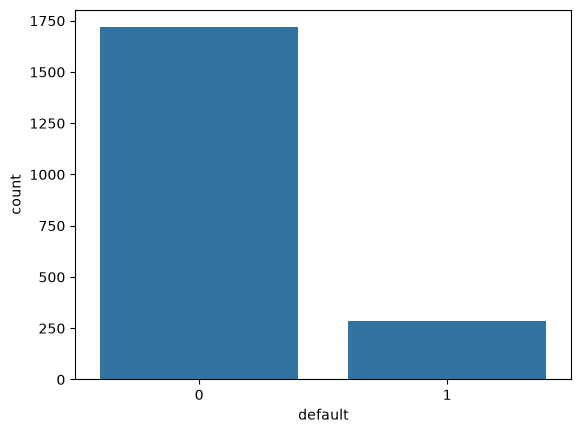

In [29]:
sns.countplot(x = base_credit['default']);

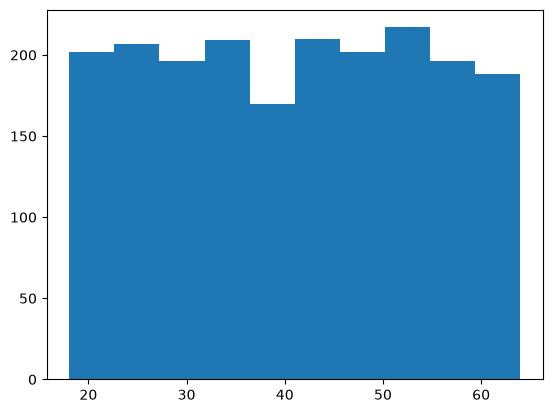

In [28]:
plt.hist(x = base_credit['age']);

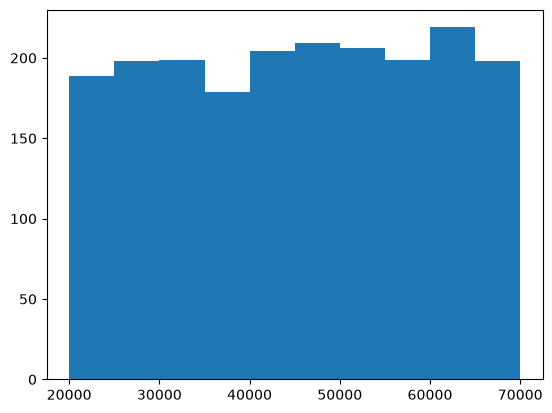

In [27]:
plt.hist(x = base_credit['income']);

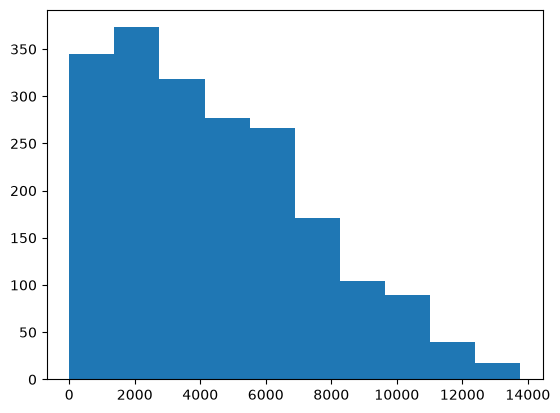

In [26]:
plt.hist(x=base_credit['loan']);

In [25]:
grafico = px.scatter_matrix(base_credit, dimensions=['age', 'income', 'loan'], color = 'default')
grafico.show()

# TRATAMENTO DE VALORES INCONSISTENTES

In [6]:
base_credit.loc[base_credit['age'] < 0]

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


In [7]:
base_credit[base_credit['age'] < 0]

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


In [ ]:
# Maneira numero 1: Apagar a coluna inteira (de todos os registros da base de dados)

base_credit2 = base_credit.drop('age', axis=1)
base_credit2

,clientid,income,loan,default
0,1,66155.925095,8106.532131,0
1,2,34415.153966,6564.745018,0
2,3,57317.170063,8020.953296,0
3,4,42709.534201,6103.642260,0
4,5,66952.688845,8770.099235,1
...,...,...,...,...
1995,1996,59221.044874,1926.729397,0
1996,1997,69516.127573,3503.176156,0
1997,1998,44311.449262,5522.786693,1
1998,1999,43756.056605,1622.722598,0


In [11]:
# Maneira numero 2: Apagar somente os registros com valores inconsistentes

base_credit3 = base_credit.drop(base_credit[base_credit['age'] < 0].index)
base_credit3

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [12]:
base_credit3.loc[base_credit3['age'] < 0]

,clientid,income,age,loan,default


In [ ]:
# Maneira numero 3: Preencher os valores incositentes manualmente (o mais confiavel)

In [13]:
# Maneira numero 4: Preencher a média

base_credit.mean()

clientid     1000.500000
income      45331.600018
age            40.807559
loan         4444.369695
default         0.141500
dtype: float64

In [15]:
base_credit['age'].mean()

40.80755937840458

In [17]:
base_credit['age'][base_credit['age'] > 0].mean()

40.92770044906149

In [21]:
base_credit.loc[base_credit['age'] < 0, 'age'] = 40.92

In [22]:
base_credit.loc[base_credit['age'] < 0]

,clientid,income,age,loan,default


In [24]:
base_credit.head(27)

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
5,6,24904.064140,57.471607,15.498598,0
6,7,48430.359613,26.809132,5722.581981,0
7,8,24500.141984,32.897548,2971.003310,1
8,9,40654.892537,55.496853,4755.825280,0
9,10,25075.872771,39.776378,1409.230371,0


# TRATAMENTO DE VALORES FALTANTES

In [30]:
base_credit.isnull()

,clientid,income,age,loan,default
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
1995,False,False,False,False,False
1996,False,False,False,False,False
1997,False,False,False,False,False
1998,False,False,False,False,False


In [31]:
base_credit.isnull().sum()

clientid    0
income      0
age         3
loan        0
default     0
dtype: int64

In [32]:
base_credit.loc[pd.isnull(base_credit['age'])]

,clientid,income,age,loan,default
28,29,59417.805406,NaN,2082.625938,0
30,31,48528.852796,NaN,6155.784670,0
31,32,23526.302555,NaN,2862.010139,0


In [39]:
base_credit['age'] = base_credit['age'].fillna(base_credit['age'].mean())

In [40]:
base_credit.loc[(base_credit['clientid'] == 29) | (base_credit['clientid'] == 31) | (base_credit['clientid'] == 32)]

,clientid,income,age,loan,default
28,29,59417.805406,40.927689,2082.625938,0
30,31,48528.852796,40.927689,6155.784670,0
31,32,23526.302555,40.927689,2862.010139,0


In [41]:
base_credit.loc[base_credit['clientid'].isin([29, 31, 32])]

,clientid,income,age,loan,default
28,29,59417.805406,40.927689,2082.625938,0
30,31,48528.852796,40.927689,6155.784670,0
31,32,23526.302555,40.927689,2862.010139,0
